# 03 — Ricerca dei parametri Praat: fase B (ricerca casuale) e fase C (conferma)

**Scopo.** Scegliere i 4 parametri (silence threshold, octave cost, octave-jump cost, voiced/unvoiced cost) e la finestra (100 o 200 ms).
La LSTM usata qui è **solo uno strumento di misura**.

**Protocollo**
- stesso campione della fase A: 1.000 file casuali del train, seed 42
- 24 configurazioni casuali nei range fissati dalla fase A + la configurazione standard di Praat;
- finestre da 100 e 200 ms;
- validazione incrociata a 3 fold **per speaker**, con i bona fide bilanciati tra i fold;
- EER calcolata sulle predizioni di tutti i fold messe insieme (*pooled*);
- riferimento senza training: EER usando solo la **frazione di finestre senza voce**
- fase C: le 3 combinazioni migliori + la standard, ripetute con 3 seed.


In [1]:
import os, sys, re, json, time, math, subprocess
from pathlib import Path
from concurrent.futures import ProcessPoolExecutor
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt
from parselmouth.praat import call
import torch
import torch.nn as nn
from torch.nn.utils.rnn import pack_padded_sequence, PackedSequence

try:
    import parselmouth
except ImportError:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "praat-parselmouth"], check=True)
    import parselmouth
from parselmouth.praat import call

INPUT_ROOT = Path(os.environ.get("INPUT_ROOT", "/kaggle/input"))
OUT_DIR = Path(os.environ.get("OUT_DIR", "/kaggle/working/praat_search_B"))
OUT_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR = OUT_DIR / "features_cache"; CACHE_DIR.mkdir(exist_ok=True)

SEED = 42
N_FILES = int(os.environ.get("N_FILES", 1000))
N_RANDOM = int(os.environ.get("N_RANDOM", 24))       # configurazioni casuali (+ la standard)
N_WORKERS = os.cpu_count() or 1
torch.set_num_threads(N_WORKERS)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# --- Parametri fissi (identici al notebook 02) ---
PITCH_FLOOR, PITCH_CEILING = 75.0, 500.0
MAX_CANDIDATES, VERY_ACCURATE, VOICING_THRESHOLD, TIME_STEP = 15, "no", 0.45, 0.0
PERIOD_FLOOR, PERIOD_CEILING = 0.8 / PITCH_CEILING, 1.25 / PITCH_FLOOR
MAX_PERIOD_FACTOR, MAX_AMPLITUDE_FACTOR = 1.3, 1.6
HNR_TIME_STEP, HNR_SILENCE, HNR_PERIODS = 0.01, 0.1, 1.0

STANDARD = {"silence_threshold": 0.03, "octave_cost": 0.01,
            "octave_jump_cost": 0.35, "voiced_unvoiced_cost": 0.14}
# Range fissati dai risultati della fase A (modificabili)
RANGES = {"silence_threshold": (0.01, 0.20), "octave_cost": (0.00, 0.20),
          "octave_jump_cost": (0.00, 1.00), "voiced_unvoiced_cost": (0.10, 1.00)}
WINDOWS_MS = [100, 200]
FEATURES = ["f0_mean", "f0_std", "jitter_local", "shimmer_local",
            "hnr_mean", "hnr_std", "intensity_mean", "intensity_std"]

# --- Training (Model A di Pitch Imperfect, budget ridotto) ---
N_FOLDS = 3
EPOCHS = int(os.environ.get("EPOCHS", 15))
EPOCHS_CHECK = int(os.environ.get("EPOCHS_CHECK", 40))   # controllo preliminare delle epoche
BATCH_SIZE = 32                                           # Pitch Imperfect, Fig. 3
LR = 1e-3                                                 # paper: 1e-4 con 200 epoche
SEEDS_C = [0, 1, 2]
TOP_K = 3

print(f"parselmouth {parselmouth.__version__} | Praat {parselmouth.PRAAT_VERSION} | torch {torch.__version__} "
      f"| device {DEVICE} | core {N_WORKERS}")

parselmouth 0.4.7 | Praat 6.1.38 | torch 2.10.0+cu128 | device cuda | core 4


In [2]:
def find_la_root(root):
    for dirpath, dirnames, _ in os.walk(root):
        dirnames[:] = [d for d in dirnames if d != "flac"]
        if "ASVspoof2019_LA_cm_protocols" in dirnames:
            return Path(dirpath)
    raise RuntimeError("Cartella con ASVspoof2019_LA_cm_protocols non trovata.")

LA_ROOT = find_la_root(INPUT_ROOT)
proto = [p for p in (LA_ROOT / "ASVspoof2019_LA_cm_protocols").iterdir() if re.search(r"cm[._]train[._]trn", p.name)]
assert len(proto) == 1, proto
train = pd.read_csv(proto[0], sep=r"\s+", header=None, dtype=str, keep_default_na=False, engine="python",
                    names=["speaker", "utt_id", "unused", "attack", "label"])
train["attack"] = train["attack"].replace("-", "bonafide")
train["path"] = [str(LA_ROOT / "ASVspoof2019_LA_train" / "flac" / f"{u}.flac") for u in train["utt_id"]]
sample = train.sample(n=min(N_FILES, len(train)), random_state=SEED).reset_index(drop=True)
sample["y"] = (sample["label"] == "bonafide").astype(np.float32)     # 1 = bona fide

# Verifica contro il campione della fase A, se il suo output è tra gli input
prev = [Path(d) / f for d, _, fs in os.walk(INPUT_ROOT) for f in fs if f == "sample_1000.csv"]
if prev:
    same = pd.read_csv(prev[0])["utt_id"].tolist() == sample["utt_id"].tolist()
    print("Campione identico alla fase A:", same)
    assert same, "Il campione differisce da quello della fase A"
else:
    print("Output della fase A non trovato tra gli input: verifica del campione saltata.")

# Fold per speaker, bilanciando i bona fide (assegnazione greedy deterministica)
spk = sample.groupby("speaker").agg(n_bona=("y", "sum"), n=("y", "size")).reset_index()
spk = spk.sort_values(["n_bona", "n", "speaker"], ascending=[False, False, True])
fold_bona, fold_n, spk_fold = [0] * N_FOLDS, [0] * N_FOLDS, {}
for r in spk.itertuples():
    f = min(range(N_FOLDS), key=lambda k: (fold_bona[k], fold_n[k]))
    spk_fold[r.speaker] = f; fold_bona[f] += r.n_bona; fold_n[f] += r.n
sample["fold"] = sample["speaker"].map(spk_fold)
sample[["utt_id", "speaker", "attack", "label", "fold"]].to_csv(OUT_DIR / "sample_folds.csv", index=False)
print(sample.groupby("fold").agg(file=("y", "size"), bona_fide=("y", "sum"), speaker=("speaker", "nunique")))

Output della fase A non trovato tra gli input: verifica del campione saltata.
      file  bona_fide  speaker
fold                          
0      296       30.0        6
1      368       31.0        7
2      336       31.0        7


In [3]:
rng = np.random.default_rng(SEED)
CONFIGS = [("standard", dict(STANDARD))]
for i in range(N_RANDOM):
    cfg = {p: round(float(rng.uniform(lo, hi)), 3) for p, (lo, hi) in RANGES.items()}
    CONFIGS.append((f"rand{i:02d}", cfg))
cfg_table = pd.DataFrame({cid: c for cid, c in CONFIGS}).T
cfg_table.to_csv(OUT_DIR / "configs.csv")
cfg_table

,silence_threshold,octave_cost,octave_jump_cost,voiced_unvoiced_cost
standard,0.030,0.010,0.350,0.140
rand00,0.157,0.088,0.859,0.728
rand01,0.028,0.195,0.761,0.807
rand02,0.034,0.090,0.371,0.934
rand03,0.132,0.165,0.443,0.305
rand04,0.115,0.013,0.828,0.668
rand05,0.154,0.071,0.971,0.904
rand06,0.158,0.039,0.467,0.139
rand07,0.039,0.137,0.745,0.971
rand08,0.072,0.074,0.470,0.271


In [4]:
def make_windows(duration, w):
    starts = np.arange(0.0, duration, w)
    ends = np.minimum(starts + w, duration)
    keep = (ends - starts) >= w / 2
    return starts[keep], ends[keep]

def window_features(snd, pp, harm_t, harm_v, int_t, int_v, a, b, pitch_t, f0):
    f0w = f0[(pitch_t >= a) & (pitch_t < b)]
    f0w = f0w[f0w > 0]
    if len(f0w) == 0:
        return np.zeros(len(FEATURES)), False
    out = np.full(len(FEATURES), np.nan)
    out[0] = f0w.mean()
    out[1] = f0w.std() if len(f0w) >= 2 else np.nan
    try:
        out[2] = call(pp, "Get jitter (local)", a, b, PERIOD_FLOOR, PERIOD_CEILING, MAX_PERIOD_FACTOR)
    except Exception:
        pass
    try:
        out[3] = call([snd, pp], "Get shimmer (local)", a, b, PERIOD_FLOOR, PERIOD_CEILING,
                      MAX_PERIOD_FACTOR, MAX_AMPLITUDE_FACTOR)
    except Exception:
        pass
    hw = harm_v[(harm_t >= a) & (harm_t < b)]
    hw = hw[hw > -100]
    if len(hw):
        out[4] = hw.mean(); out[5] = hw.std() if len(hw) >= 2 else np.nan
    iw = int_v[(int_t >= a) & (int_t < b)]
    iw = iw[np.isfinite(iw)]
    if len(iw):
        out[6] = iw.mean(); out[7] = iw.std() if len(iw) >= 2 else np.nan
    return out, True

def extract(args):
    # Restituisce {window_ms: matrice (n_finestre, 8) float32} con NaN -> 0 e silenzio -> 0
    path, cfg = args
    snd = parselmouth.Sound(path)
    harm = call(snd, "To Harmonicity (cc)", HNR_TIME_STEP, PITCH_FLOOR, HNR_SILENCE, HNR_PERIODS)
    inten = snd.to_intensity(minimum_pitch=PITCH_FLOOR)
    pitch = call(snd, "To Pitch (cc)", TIME_STEP, PITCH_FLOOR, MAX_CANDIDATES, VERY_ACCURATE,
                 cfg["silence_threshold"], VOICING_THRESHOLD, cfg["octave_cost"],
                 cfg["octave_jump_cost"], cfg["voiced_unvoiced_cost"], PITCH_CEILING)
    pp = call([snd, pitch], "To PointProcess (cc)")
    ht, hv = np.asarray(harm.xs()), np.asarray(harm.values[0])
    it, iv = np.asarray(inten.xs()), np.asarray(inten.values[0])
    pt, f0 = np.asarray(pitch.xs()), np.asarray(pitch.selected_array["frequency"])
    out = {}
    for w_ms in WINDOWS_MS:
        starts, ends = make_windows(snd.duration, w_ms / 1000)
        X = np.zeros((len(starts), len(FEATURES)), dtype=np.float32)
        for i, (a, b) in enumerate(zip(starts, ends)):
            vec, _ = window_features(snd, pp, ht, hv, it, iv, a, b, pt, f0)
            X[i] = np.nan_to_num(vec, nan=0.0)
        if len(X) == 0:                                   # file più corto di mezza finestra
            X = np.zeros((1, len(FEATURES)), dtype=np.float32)
        out[w_ms] = X
    return out

def get_features(cfg_id, cfg):
    # Carica dalla cache o estrae; restituisce {window_ms: lista di matrici nell'ordine del campione}
    cache = CACHE_DIR / f"{cfg_id}.npz"
    if cache.exists():
        z = np.load(cache, allow_pickle=True)
        return {w: list(z[f"w{w}"]) for w in WINDOWS_MS}
    with ProcessPoolExecutor(max_workers=N_WORKERS) as ex:
        res = list(ex.map(extract, [(p, cfg) for p in sample["path"]], chunksize=8))
    feats = {w: [r[w] for r in res] for w in WINDOWS_MS}
    arrs = {}
    for w in WINDOWS_MS:
        a = np.empty(len(feats[w]), dtype=object); a[:] = feats[w]; arrs[f"w{w}"] = a
    np.savez(cache, **arrs)
    return feats

t0 = time.perf_counter()
FEATS = {"standard": get_features("standard", STANDARD)}
t_cfg = time.perf_counter() - t0
print(f"Estrazione configurazione standard: {t_cfg / 60:.1f} min "
      f"-> stima per tutte le {len(CONFIGS)} configurazioni: ~{t_cfg * len(CONFIGS) / 60:.0f} min")
lens = {w: np.array([len(x) for x in FEATS['standard'][w]]) for w in WINDOWS_MS}
for w in WINDOWS_MS:
    print(f"{w} ms: finestre per file min {lens[w].min()}, mediana {np.median(lens[w]):.0f}, max {lens[w].max()}")

Estrazione configurazione standard: 1.1 min -> stima per tutte le 25 configurazioni: ~28 min
100 ms: finestre per file min 8, mediana 32, max 102
200 ms: finestre per file min 4, mediana 16, max 51


In [5]:
class ModelA(nn.Module):
    def __init__(self, n_in=len(FEATURES)):
        super().__init__()
        self.drop_in1, self.lstm1, self.bn1 = nn.Dropout(0.2), nn.LSTM(n_in, 64, batch_first=True), nn.BatchNorm1d(64)
        self.drop_in2, self.lstm2, self.bn2 = nn.Dropout(0.2), nn.LSTM(64, 32, batch_first=True), nn.BatchNorm1d(32)
        self.head = nn.Sequential(nn.Linear(32, 32), nn.ReLU(), nn.Dropout(0.2), nn.Linear(32, 1))

    @staticmethod
    def _map(packed, fn):
        return PackedSequence(fn(packed.data), packed.batch_sizes, packed.sorted_indices, packed.unsorted_indices)

    def forward(self, x, lengths):
        p = pack_padded_sequence(x, lengths.cpu(), batch_first=True, enforce_sorted=False)
        p = self._map(p, self.drop_in1)
        p, _ = self.lstm1(p)
        p = self._map(p, self.bn1)          # BatchNorm sui soli passi validi
        p = self._map(p, self.drop_in2)
        _, (h, _) = self.lstm2(p)           # h: ultimo stato valido di ogni sequenza
        return self.head(self.bn2(h[-1])).squeeze(-1)

def compute_eer(y, s):
    fpr, tpr, _ = roc_curve(y, s, pos_label=1)
    fnr = 1 - tpr
    i = np.nanargmin(np.abs(fnr - fpr))
    return float((fpr[i] + fnr[i]) / 2)

def minmax_fit(seqs):
    allw = np.concatenate(seqs, axis=0)
    lo, hi = allw.min(0), allw.max(0)
    return lo, np.where(hi - lo > 0, hi - lo, 1.0)

def make_batch(seqs, idx, lo, rng_):
    X = [(seqs[i] - lo) / rng_ for i in idx]
    L = torch.tensor([len(x) for x in X])
    B = torch.zeros(len(X), int(L.max()), X[0].shape[1])
    for k, x in enumerate(X):
        B[k, :len(x)] = torch.from_numpy(x.astype(np.float32))
    return B, L

def predict(model, seqs, idx, lo, rng_):
    model.eval(); out = []
    with torch.no_grad():
        for k in range(0, len(idx), 256):
            B, L = make_batch(seqs, idx[k:k + 256], lo, rng_)
            out.append(model(B.to(DEVICE), L).cpu().numpy())
    return np.concatenate(out)

def train_fold(seqs, y, tr_idx, va_idx, seed, epochs, track=False):
    torch.manual_seed(seed); np.random.seed(seed)
    tr_seqs = [seqs[i] for i in tr_idx]
    lo, rng_ = minmax_fit(tr_seqs)                        # solo sul training fold
    model = ModelA().to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=LR)
    pos_w = (y[tr_idx] == 0).sum() / max((y[tr_idx] == 1).sum(), 1)   # bilanciamento classi
    loss_fn = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(pos_w, dtype=torch.float32, device=DEVICE))
    g = np.random.default_rng(seed)
    history = []
    for ep in range(epochs):
        model.train()
        perm = g.permutation(tr_idx)
        for k in range(0, len(perm), BATCH_SIZE):
            b = perm[k:k + BATCH_SIZE]
            if len(b) < 2:
                continue                                   # BatchNorm richiede almeno 2 esempi
            B, L = make_batch(seqs, b, lo, rng_)
            loss = loss_fn(model(B.to(DEVICE), L), torch.from_numpy(y[b]).to(DEVICE))
            opt.zero_grad(); loss.backward(); opt.step()
        if track:
            history.append(compute_eer(y[va_idx], predict(model, seqs, va_idx, lo, rng_)))
    return predict(model, seqs, va_idx, lo, rng_), history

def cross_validate(seqs, seed, epochs=EPOCHS):
    y, folds = sample["y"].to_numpy(), sample["fold"].to_numpy()
    scores = np.zeros(len(y)); per_fold = []
    for f in range(N_FOLDS):
        tr, va = np.where(folds != f)[0], np.where(folds == f)[0]
        s, _ = train_fold(seqs, y, tr, va, seed, epochs)
        scores[va] = s; per_fold.append(compute_eer(y[va], s))
    return compute_eer(y, scores), float(np.mean(per_fold)), float(np.std(per_fold))

def silence_baseline(seqs):
    # EER usando solo la frazione di finestre senza voce; direzione stimata sui fold di training
    y, folds = sample["y"].to_numpy(), sample["fold"].to_numpy()
    frac = np.array([(np.abs(x).sum(1) == 0).mean() for x in seqs])
    scores = np.zeros(len(y))
    for f in range(N_FOLDS):
        tr, va = folds != f, folds == f
        sign = 1.0 if frac[tr][y[tr] == 1].mean() >= frac[tr][y[tr] == 0].mean() else -1.0
        scores[va] = sign * frac[va]
    return compute_eer(y, scores)

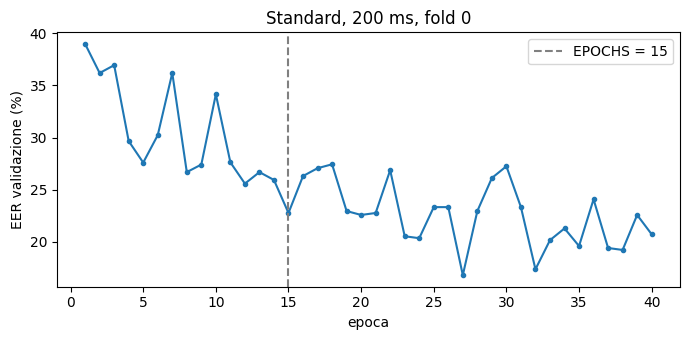

Tempo per epoca (un fold): 0.32 s -> stima training fase B: ~12 min
EER a epoca 15: 22.76% | minima: 16.79% (epoca 27)


In [6]:
y_all, folds_all = sample["y"].to_numpy(), sample["fold"].to_numpy()
tr0, va0 = np.where(folds_all != 0)[0], np.where(folds_all == 0)[0]
t0 = time.perf_counter()
_, hist = train_fold(FEATS["standard"][200], y_all, tr0, va0, seed=0, epochs=EPOCHS_CHECK, track=True)
t_ep = (time.perf_counter() - t0) / EPOCHS_CHECK
plt.figure(figsize=(7, 3.5))
plt.plot(range(1, EPOCHS_CHECK + 1), 100 * np.array(hist), marker=".")
plt.axvline(EPOCHS, color="gray", ls="--", label=f"EPOCHS = {EPOCHS}")
plt.xlabel("epoca"); plt.ylabel("EER validazione (%)"); plt.title("Standard, 200 ms, fold 0"); plt.legend()
plt.tight_layout(); plt.savefig(OUT_DIR / "epoch_check.png", dpi=120); plt.show()
n_train = len(CONFIGS) * len(WINDOWS_MS) * N_FOLDS
print(f"Tempo per epoca (un fold): {t_ep:.2f} s -> stima training fase B: ~{n_train * EPOCHS * t_ep / 60:.0f} min")
print(f"EER a epoca {EPOCHS}: {100 * hist[EPOCHS - 1]:.2f}% | minima: {100 * min(hist):.2f}% (epoca {int(np.argmin(hist)) + 1})")

In [7]:
RES_B = OUT_DIR / "phaseB_results.csv"
done = pd.read_csv(RES_B) if RES_B.exists() else pd.DataFrame()
t0 = time.perf_counter()
for cfg_id, cfg in tqdm(CONFIGS, desc="configurazioni"):
    if len(done) and (done["cfg_id"] == cfg_id).sum() == len(WINDOWS_MS):
        continue
    feats = FEATS.get(cfg_id) or get_features(cfg_id, cfg)
    rows = []
    for w in WINDOWS_MS:
        eer_pooled, eer_mean, eer_std = cross_validate(feats[w], seed=0)
        zero_frac = float(np.mean([(np.abs(x).sum(1) == 0).mean() for x in feats[w]]))
        rows.append({"cfg_id": cfg_id, "window_ms": w, **cfg,
                     "eer_pooled": eer_pooled, "eer_fold_mean": eer_mean, "eer_fold_std": eer_std,
                     "eer_silence_baseline": silence_baseline(feats[w]), "zero_window_frac": zero_frac})
    done = pd.concat([done, pd.DataFrame(rows)], ignore_index=True)
    done.to_csv(RES_B, index=False)
    if cfg_id != "standard":
        FEATS.pop(cfg_id, None)          # libera memoria: le feature restano in cache su disco
print(f"Fase B completata in {(time.perf_counter() - t0) / 60:.1f} min")

resB = pd.read_csv(RES_B)
show = resB.assign(**{c: (100 * resB[c]).round(2) for c in ["eer_pooled", "eer_fold_mean", "eer_fold_std", "eer_silence_baseline"]})
show.sort_values("eer_pooled").head(15)

configurazioni:   0%|          | 0/25 [00:00<?, ?it/s]

Fase B completata in 32.3 min


,cfg_id,window_ms,silence_threshold,octave_cost,octave_jump_cost,voiced_unvoiced_cost,eer_pooled,eer_fold_mean,eer_fold_std,eer_silence_baseline,zero_window_frac
37,rand17,200,0.016,0.087,0.215,0.468,19.03,20.27,3.94,37.26,0.330910
39,rand18,200,0.172,0.047,0.058,0.353,20.90,21.56,6.17,39.11,0.366931
47,rand22,200,0.041,0.100,0.152,0.727,21.61,22.18,3.23,37.04,0.367819
21,rand09,200,0.035,0.095,0.227,0.703,21.94,22.52,4.66,37.96,0.363214
3,rand00,200,0.157,0.088,0.859,0.728,22.16,22.24,0.78,38.74,0.430925
35,rand16,200,0.131,0.111,0.559,0.374,22.70,24.12,0.89,39.61,0.382969
45,rand21,200,0.014,0.018,0.722,0.516,23.09,23.02,0.77,36.49,0.319725
41,rand19,200,0.066,0.132,0.557,0.806,23.20,24.77,4.02,38.16,0.436298
49,rand23,200,0.095,0.076,0.302,0.667,23.47,22.39,4.60,39.17,0.368277
33,rand15,200,0.137,0.094,0.565,0.788,23.74,22.79,4.55,38.25,0.424539


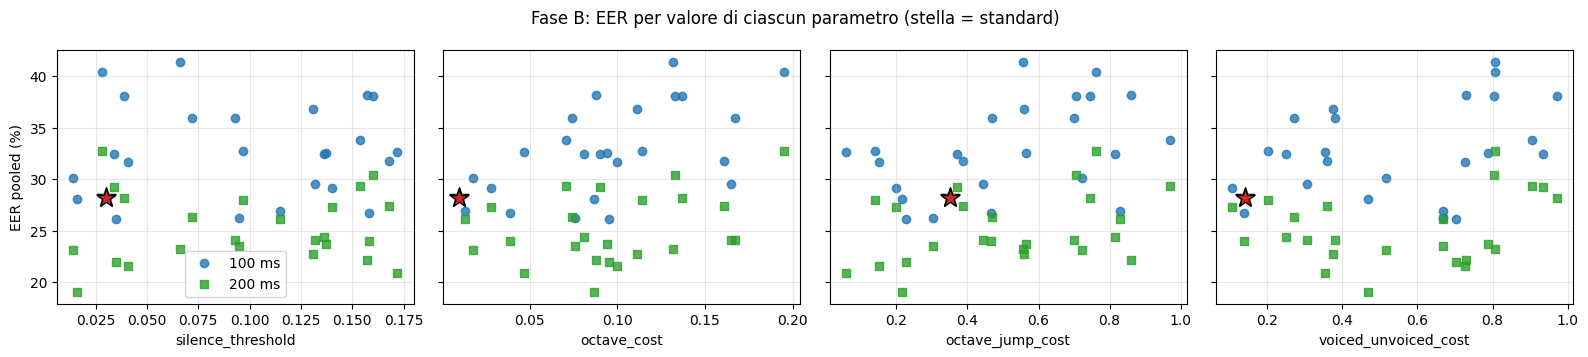

In [8]:
fig, axes = plt.subplots(1, 4, figsize=(16, 3.6), sharey=True)
for ax, p in zip(axes, RANGES):
    for w, m in zip(WINDOWS_MS, ["o", "s"]):
        d = resB[resB["window_ms"] == w]
        ax.scatter(d[p], 100 * d["eer_pooled"], marker=m, label=f"{w} ms", alpha=0.8)
        st = d[d["cfg_id"] == "standard"]
        ax.scatter(st[p], 100 * st["eer_pooled"], marker="*", s=200, edgecolor="k")
    ax.set_xlabel(p); ax.grid(alpha=0.3)
axes[0].set_ylabel("EER pooled (%)"); axes[0].legend()
plt.suptitle("Fase B: EER per valore di ciascun parametro (stella = standard)")
plt.tight_layout(); plt.savefig(OUT_DIR / "phaseB_scatter.png", dpi=120); plt.show()

In [9]:
top = resB.sort_values("eer_pooled").head(TOP_K)[["cfg_id", "window_ms"]]
std_rows = pd.DataFrame({"cfg_id": "standard", "window_ms": WINDOWS_MS})
cand = pd.concat([top, std_rows]).drop_duplicates().reset_index(drop=True)
cfg_map = dict(CONFIGS)

RES_C = OUT_DIR / "phaseC_results.csv"
rowsC = pd.read_csv(RES_C).to_dict("records") if RES_C.exists() else []
done_c = {(r["cfg_id"], r["window_ms"], r["seed"]) for r in rowsC}
for r in tqdm(cand.itertuples(), total=len(cand), desc="fase C"):
    feats = get_features(r.cfg_id, cfg_map[r.cfg_id])
    for sd in SEEDS_C:
        if (r.cfg_id, r.window_ms, sd) in done_c:
            continue
        eer_pooled, _, _ = cross_validate(feats[r.window_ms], seed=sd)
        rowsC.append({"cfg_id": r.cfg_id, "window_ms": r.window_ms, "seed": sd, "eer_pooled": eer_pooled})
        pd.DataFrame(rowsC).to_csv(RES_C, index=False)

resC = pd.DataFrame(rowsC)
summaryC = (resC.groupby(["cfg_id", "window_ms"])["eer_pooled"]
            .agg(eer_mean="mean", eer_std="std", n_seed="size").mul([100, 100, 1]).round(2)
            .join(resB.set_index(["cfg_id", "window_ms"])[list(RANGES) + ["eer_silence_baseline"]])
            .sort_values("eer_mean"))
summaryC["eer_silence_baseline"] = (100 * summaryC["eer_silence_baseline"]).round(2)
summaryC.to_csv(OUT_DIR / "phaseC_summary.csv")
summaryC

fase C:   0%|          | 0/5 [00:00<?, ?it/s]

eer_mean  eer_std  n_seed  silence_threshold  octave_cost  \
cfg_id   window_ms                                                              
rand18   200           22.67     1.59       3              0.172        0.047   
rand17   200           22.70     3.59       3              0.016        0.087   
rand22   200           25.20     3.12       3              0.041        0.100   
standard 200           26.84     2.30       3              0.030        0.010   
         100           31.20     4.23       3              0.030        0.010   

                    octave_jump_cost  voiced_unvoiced_cost  \
cfg_id   window_ms                                           
rand18   200                   0.058                 0.353   
rand17   200                   0.215                 0.468   
rand22   200                   0.152                 0.727   
standard 200                   0.350                 0.140   
         100                   0.350                 0.140   

                    eer_silence_baseline  
cfg_id   window_ms                        
rand18   200                       39.11  
rand17   200                       37.26  
rand22   200                       37.04  
standard 200                       38.07  
         100                       36.82

In [10]:
meta = {"seed": SEED, "n_files": len(sample), "n_folds": N_FOLDS, "epochs": EPOCHS, "lr": LR,
        "batch_size": BATCH_SIZE, "seeds_phaseC": SEEDS_C, "ranges": RANGES, "standard": STANDARD,
        "windows_ms": WINDOWS_MS, "features": FEATURES, "device": DEVICE,
        "praat_version": parselmouth.PRAAT_VERSION, "parselmouth_version": parselmouth.__version__,
        "torch_version": torch.__version__,
        "folds": sample.groupby("fold").agg(n=("y", "size"), bona=("y", "sum")).reset_index().to_dict("records")}
(OUT_DIR / "phaseBC_meta.json").write_text(json.dumps(meta, indent=2, default=float))
print("Salvati in", OUT_DIR, ":", sorted(p.name for p in OUT_DIR.iterdir()))

Salvati in /kaggle/working/praat_search_B : ['configs.csv', 'epoch_check.png', 'features_cache', 'phaseBC_meta.json', 'phaseB_results.csv', 'phaseB_scatter.png', 'phaseC_results.csv', 'phaseC_summary.csv', 'sample_folds.csv']
